['gender', 'age', 'smoke', 'drink', 'air_pollution', 'water_pollution', 'stress', 'fatigue', 'weight_loss', 'loss_of_appetite', 'fever', 'cough', 'shortness_of_breath', 'chest_pain', 'abdominal_pain', 'jaundice']

Probability comparison as features are added:

          Added Feature  LR P(Liver)  LR P(Lung)  NB P(Liver)  NB P(Lung)
0                gender     0.377667    0.622333     0.351762    0.648238
1                   age     0.375276    0.624724     0.351762    0.648238
2                 smoke     0.245560    0.754440     0.190163    0.809837
3                 drink     0.620584    0.379416     0.453882    0.546118
4         air_pollution     0.372315    0.627685     0.207755    0.792245
5       water_pollution     0.591674    0.408326     0.454122    0.545878
6                stress     0.627845    0.372155     0.477885    0.522115
7               fatigue     0.627433    0.372567     0.480536    0.519464
8           weight_loss     0.656561    0.343439     0.467279    0.532721

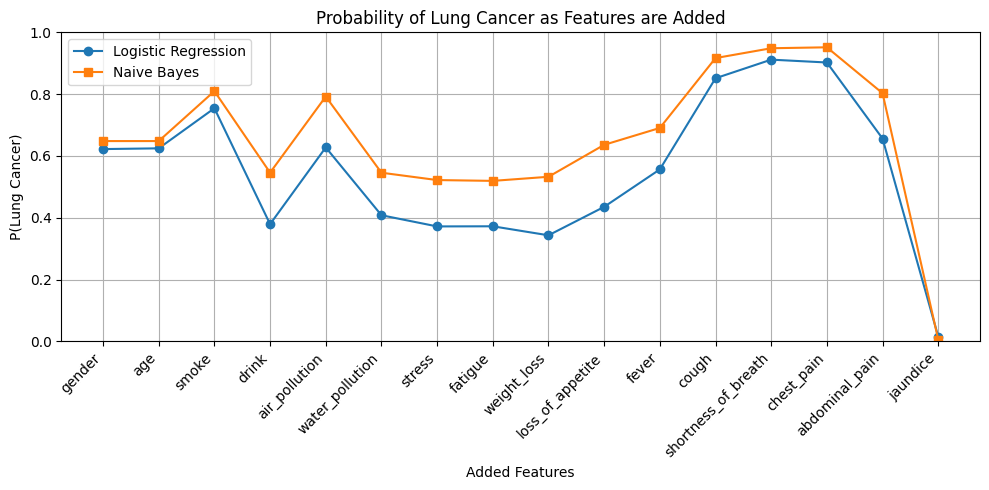

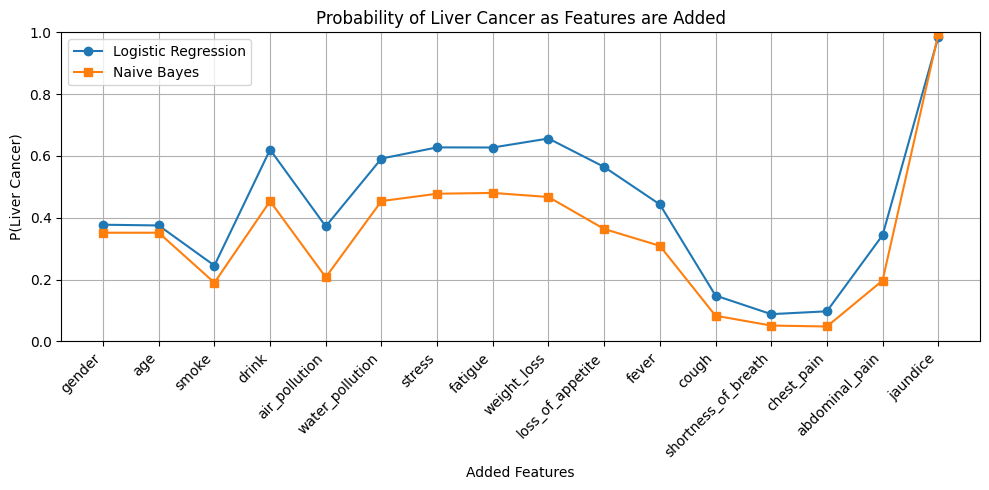

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import BernoulliNB
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder


# ===============================
# Load dataset
# ===============================
df = pd.read_csv("disease_dataset_1000.csv")

df["target"] = (df["diagnosis"] == "lung").astype(int)
df["gender"] = LabelEncoder().fit_transform(df["gender"])

X = df.drop(columns=["diagnosis", "target"])
y = df["target"]

# ===============================
# Feature order (ONLY existing ones)
# ===============================
feature_order = list(X.columns)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
print(list(X.columns))


# ===============================
# Train models
# ===============================
log_reg = LogisticRegression(max_iter=1000)
nb = BernoulliNB()

log_reg.fit(X_train, y_train)
nb.fit(X_train, y_train)

# ===============================
# Base person: no risk factors
# ===============================
base_sample = pd.DataFrame(
    np.zeros((1, X.shape[1])),
    columns=X.columns
)

results = []
current_sample = base_sample.copy()

for feature in feature_order:
    current_sample[feature] = 1

    lr_prob = log_reg.predict_proba(current_sample)[0]
    nb_prob = nb.predict_proba(current_sample)[0]

    results.append({
        "Added Feature": feature,
        "LR P(Liver)": lr_prob[0],
        "LR P(Lung)": lr_prob[1],
        "NB P(Liver)": nb_prob[0],
        "NB P(Lung)": nb_prob[1],
    })

results_df = pd.DataFrame(results)
print("\nProbability comparison as features are added:\n")
print(results_df)

# ===============================
# Visualization: Lung Cancer
# ===============================
plt.figure(figsize=(10, 5))
plt.plot(
    results_df["Added Feature"],
    results_df["LR P(Lung)"],
    marker="o",
    label="Logistic Regression"
)
plt.plot(
    results_df["Added Feature"],
    results_df["NB P(Lung)"],
    marker="s",
    label="Naive Bayes"
)

plt.ylabel("P(Lung Cancer)")
plt.xlabel("Added Features")
plt.title("Probability of Lung Cancer as Features are Added")
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.ylim(0, 1)
plt.grid(True)
plt.tight_layout()
plt.show()


# ===============================
# Visualization: Liver Cancer
# ===============================
plt.figure(figsize=(10, 5))
plt.plot(
    results_df["Added Feature"],
    results_df["LR P(Liver)"],
    marker="o",
    label="Logistic Regression"
)
plt.plot(
    results_df["Added Feature"],
    results_df["NB P(Liver)"],
    marker="s",
    label="Naive Bayes"
)

plt.ylabel("P(Liver Cancer)")
plt.xlabel("Added Features")
plt.title("Probability of Liver Cancer as Features are Added")
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.ylim(0, 1)
plt.grid(True)
plt.tight_layout()
plt.show()